# Module 1 — Outlier Detection & Imbalanced Learning
**Course:** Data Mining 2 | **Dataset:** Child Mind Institute – Problematic Internet Use  

This notebook covers two tasks:
1. **Outlier Detection** — LOF + ABOD + Isolation Forest ensemble (majority vote)
2. **Imbalanced Learning** — SMOTE / ENN / SMOTEENN sensitivity analysis on the rarest class (sii=3 vs rest) using a Decision Tree

---
> **Prerequisite:** Run `00_data_understanding.ipynb` first.

## 1.0 — Setup: Imports and Paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Outlier detection ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from pyod.models.abod import ABOD

# ── Imbalanced learning ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110

OUT_DIR = '../outputs/'

X_train = pd.read_csv(OUT_DIR + 'X_train_processed.csv')
y_train = pd.read_csv(OUT_DIR + 'y_train.csv')['sii']

print(f"Train: {X_train.shape}  |  Class dist: {y_train.value_counts(normalize=True).sort_index().round(3).to_dict()}")

Train: (6345, 107)  |  Class dist: {0.0: 0.69, 1.0: 0.188, 2.0: 0.113, 3.0: 0.01}


## Part A — Outlier Detection

### Strategy
Three complementary methods are combined via **majority voting** (flagged by ≥ 2 of 3 = outlier):

| Method | What it detects | Threshold |
|--------|----------------|-----------|
| **LOF** | Low-density neighbourhoods | 10th percentile of score |
| **ABOD** | Geometric outliers (angle variance) | 90th percentile of score |
| **Isolation Forest** | Easily isolated points | 5th percentile of decision function |

All features are standardised (zero mean, unit variance) before applying LOF and ABOD.

## 1.1 — Standardise Features

In [2]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
print(f"Scaled matrix: {X_scaled.shape}")

Scaled matrix: (6345, 107)


## 1.2 — Local Outlier Factor (LOF)

In [3]:
lof = LocalOutlierFactor(n_neighbors=50, novelty=False)
lof.fit_predict(X_scaled)                         # -1 = outlier, 1 = inlier
lof_scores  = lof.negative_outlier_factor_        # more negative → more outlier
lof_thresh  = np.percentile(lof_scores, 10)
lof_outlier = lof_scores <= lof_thresh

print(f"LOF outliers: {lof_outlier.sum()} ({lof_outlier.mean()*100:.2f}%)")

LOF outliers: 635 (10.01%)


## 1.3 — Angle-Based Outlier Detection (ABOD)

In [4]:
abod = ABOD(n_neighbors=50, method='fast')
abod.fit(X_scaled)
abod_scores  = abod.decision_scores_              # higher → more outlier
abod_thresh  = np.percentile(abod_scores, 90)
abod_outlier = abod_scores >= abod_thresh

print(f"ABOD outliers: {abod_outlier.sum()} ({abod_outlier.mean()*100:.2f}%)")

ABOD outliers: 635 (10.01%)


## 1.4 — Isolation Forest

In [5]:
iso = IsolationForest(n_estimators=200, max_samples=0.6, max_features=0.6,
                      random_state=RANDOM_STATE)
iso.fit(X_scaled)
iso_scores  = iso.decision_function(X_scaled)     # lower → more abnormal
iso_thresh  = np.percentile(iso_scores, 5)
iso_outlier = iso_scores <= iso_thresh

print(f"IF outliers: {iso_outlier.sum()} ({iso_outlier.mean()*100:.2f}%)")

IF outliers: 318 (5.01%)


## 1.5 — Score Distributions (Figure 1.1)

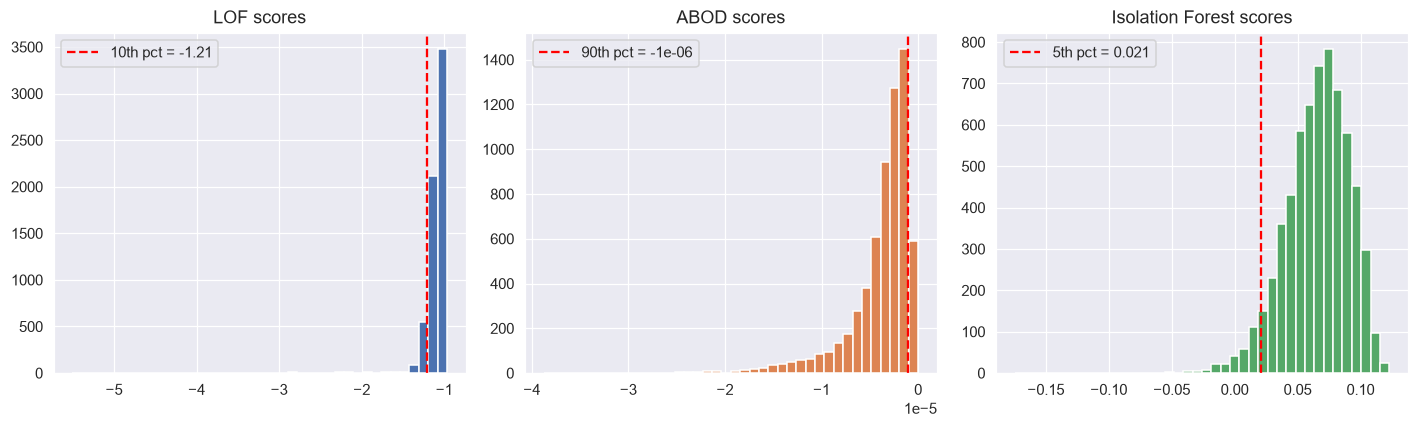

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(lof_scores, bins=40, color='#4C72B0')
axes[0].axvline(lof_thresh, color='red', linestyle='--', label=f'10th pct = {lof_thresh:.2f}')
axes[0].set_title('LOF scores'); axes[0].legend()

axes[1].hist(abod_scores, bins=40, color='#DD8452')
axes[1].axvline(abod_thresh, color='red', linestyle='--', label=f'90th pct = {abod_thresh:.2g}')
axes[1].set_title('ABOD scores'); axes[1].legend()

axes[2].hist(iso_scores, bins=40, color='#55A868')
axes[2].axvline(iso_thresh, color='red', linestyle='--', label=f'5th pct = {iso_thresh:.3f}')
axes[2].set_title('Isolation Forest scores'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig5_outlier_score_distributions.png', dpi=110)
plt.show()

## 1.6 — Majority-Vote Ensemble

In [7]:
votes           = (lof_outlier.astype(int) +
                    abod_outlier.astype(int) +
                    iso_outlier.astype(int))
ensemble_outlier = votes >= 2
n_out            = ensemble_outlier.sum()

print(f"Ensemble (>=2/3): {n_out} outliers ({ensemble_outlier.mean()*100:.2f}%)")
print(f"  Driven by ABOD: {(abod_outlier & ensemble_outlier).sum() / n_out * 100:.1f}%")
print(f"  Driven by LOF:  {(lof_outlier  & ensemble_outlier).sum() / n_out * 100:.1f}%")
print(f"  Driven by IF:   {(iso_outlier  & ensemble_outlier).sum() / n_out * 100:.1f}%")

Ensemble (>=2/3): 486 outliers (7.66%)
  Driven by ABOD: 98.6%
  Driven by LOF:  79.6%
  Driven by IF:   50.6%


## 1.7 — PCA Visualisation (Figure 1.2)

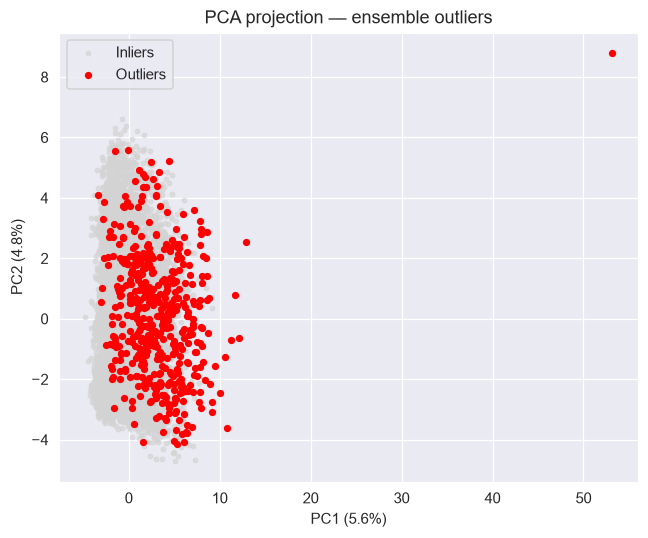

In [8]:
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_pca[~ensemble_outlier, 0], X_pca[~ensemble_outlier, 1],
           s=8, c='lightgray', label='Inliers', alpha=0.6)
ax.scatter(X_pca[ensemble_outlier, 0],  X_pca[ensemble_outlier, 1],
           s=14, c='red', label='Outliers')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA projection — ensemble outliers')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig6_pca_outliers.png', dpi=110)
plt.show()

## 1.8 — Outlier Rate per sii Class (Figure 1.3)

     sum  count        pct
sii                       
0.0  291   4375   6.651429
1.0  110   1190   9.243697
2.0   79    714  11.064426
3.0    6     66   9.090909


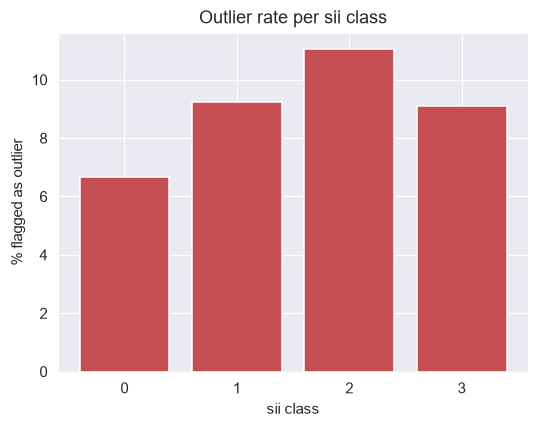

In [9]:
df_check = pd.DataFrame({'sii': y_train.values, 'outlier': ensemble_outlier})
dist_by_class = (df_check.groupby('sii')['outlier']
                  .agg(['sum', 'count'])
                  .assign(pct=lambda d: d['sum'] / d['count'] * 100))
print(dist_by_class)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(dist_by_class.index.astype(int).astype(str), dist_by_class['pct'], color='#C44E52')
ax.set_xlabel('sii class'); ax.set_ylabel('% flagged as outlier')
ax.set_title('Outlier rate per sii class')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig7_outliers_by_class.png', dpi=110)
plt.show()

## 1.9 — Remove Outliers and Save Cleaned Training Set

In [10]:
X_train_clean = X_train[~ensemble_outlier].reset_index(drop=True)
y_train_clean = y_train[~ensemble_outlier].reset_index(drop=True)

X_train_clean.to_csv(OUT_DIR + 'X_train_clean.csv', index=False)
y_train_clean.to_csv(OUT_DIR + 'y_train_clean.csv', index=False)

print(f"Train before: {X_train.shape[0]} rows")
print(f"Train after:  {X_train_clean.shape[0]} rows (removed {n_out})")

Train before: 6345 rows
Train after:  5859 rows (removed 486)


---
## Part B — Imbalanced Learning

### Problem
`sii=3` (Severe) represents ~1% of the training set — extremely rare.  
A binary one-vs-rest task (sii=3 vs rest) is used to study resampling.

### Methods tested
| Technique | Type | k values |
|-----------|------|---------|
| **SMOTE** | Oversampling | 3, 5, 7 |
| **ENN** | Undersampling | 3, 5, 7 |
| **SMOTEENN** | Combined | (3,3), (5,5), (3,5), (5,3) |

**Classifier:** Decision Tree (max_depth=6)  
**Evaluation:** Internal 70/30 stratified split from the cleaned training set

## 1.10 — Binary Target: sii=3 vs Rest

In [11]:
X    = pd.read_csv(OUT_DIR + 'X_train_clean.csv')
y    = pd.read_csv(OUT_DIR + 'y_train_clean.csv')['sii']
y_bin = (y == 3).astype(int)

print(f"Positive rate (sii=3): {y_bin.mean()*100:.2f}%  ({y_bin.sum()} cases)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_bin, test_size=0.3, stratify=y_bin, random_state=RANDOM_STATE
)
print(f"Internal train: {X_tr.shape[0]}  |  Internal test: {X_te.shape[0]}")

Positive rate (sii=3): 1.02%  (60 cases)
Internal train: 4101  |  Internal test: 1758


## 1.11 — Resampling Experiments

In [12]:
# Build configuration dictionary
configs = {'Baseline': None}
for k in [3, 5, 7]:
    configs[f'SMOTE(k={k})']         = ('smote', k)
for k in [3, 5, 7]:
    configs[f'ENN(k={k})']           = ('enn', k)
for k1, k2 in [(3,3), (5,5), (3,5), (5,3)]:
    configs[f'SMOTEENN({k1},{k2})']  = ('smoteenn', k1, k2)

results  = []
roc_data = {}

for name, cfg in configs.items():
    # ── Apply resampling ────────────────────────────────────────────────────
    if cfg is None:
        X_res, y_res = X_tr, y_tr
    elif cfg[0] == 'smote':
        sm = SMOTE(k_neighbors=cfg[1], random_state=RANDOM_STATE)
        X_res, y_res = sm.fit_resample(X_tr, y_tr)
    elif cfg[0] == 'enn':
        enn = EditedNearestNeighbours(n_neighbors=cfg[1])
        X_res, y_res = enn.fit_resample(X_tr, y_tr)
    elif cfg[0] == 'smoteenn':
        smen = SMOTEENN(smote=SMOTE(k_neighbors=cfg[1], random_state=RANDOM_STATE),
                         enn=EditedNearestNeighbours(n_neighbors=cfg[2]),
                         random_state=RANDOM_STATE)
        X_res, y_res = smen.fit_resample(X_tr, y_tr)

    # ── Train & evaluate ────────────────────────────────────────────────────
    clf    = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    results.append({
        'Technique':      name,
        'Precision':      precision_score(y_te, y_pred, zero_division=0),
        'Recall':         recall_score(y_te, y_pred, zero_division=0),
        'F1':             f1_score(y_te, y_pred, zero_division=0),
        'AUC':            roc_auc_score(y_te, y_prob),
        'Train size':     len(y_res),
        'Size change (%)': (len(y_res) - len(y_tr)) / len(y_tr) * 100,
    })
    roc_data[name] = roc_curve(y_te, y_prob)

results_df = pd.DataFrame(results)
results_df.to_csv(OUT_DIR + 'table_imbalance_results.csv', index=False)
print(results_df.round(3).to_string(index=False))

    Technique  Precision  Recall    F1   AUC  Train size  Size change (%)
     Baseline      0.000   0.000 0.000 0.547        4101            0.000
   SMOTE(k=3)      0.014   0.111 0.025 0.520        8118           97.952
   SMOTE(k=5)      0.015   0.111 0.026 0.534        8118           97.952
   SMOTE(k=7)      0.007   0.056 0.012 0.491        8118           97.952
     ENN(k=3)      0.000   0.000 0.000 0.516        3960           -3.438
     ENN(k=5)      0.000   0.000 0.000 0.517        3875           -5.511
     ENN(k=7)      0.000   0.000 0.000 0.538        3798           -7.388
SMOTEENN(3,3)      0.014   0.111 0.025 0.520        8114           97.854
SMOTEENN(5,5)      0.015   0.111 0.026 0.535        8040           96.050
SMOTEENN(3,5)      0.015   0.111 0.026 0.521        8081           97.050
SMOTEENN(5,3)      0.015   0.111 0.026 0.534        8091           97.293


## 1.12 — Visualisation: Precision / Recall / F1 / ROC (Figure 1.4)

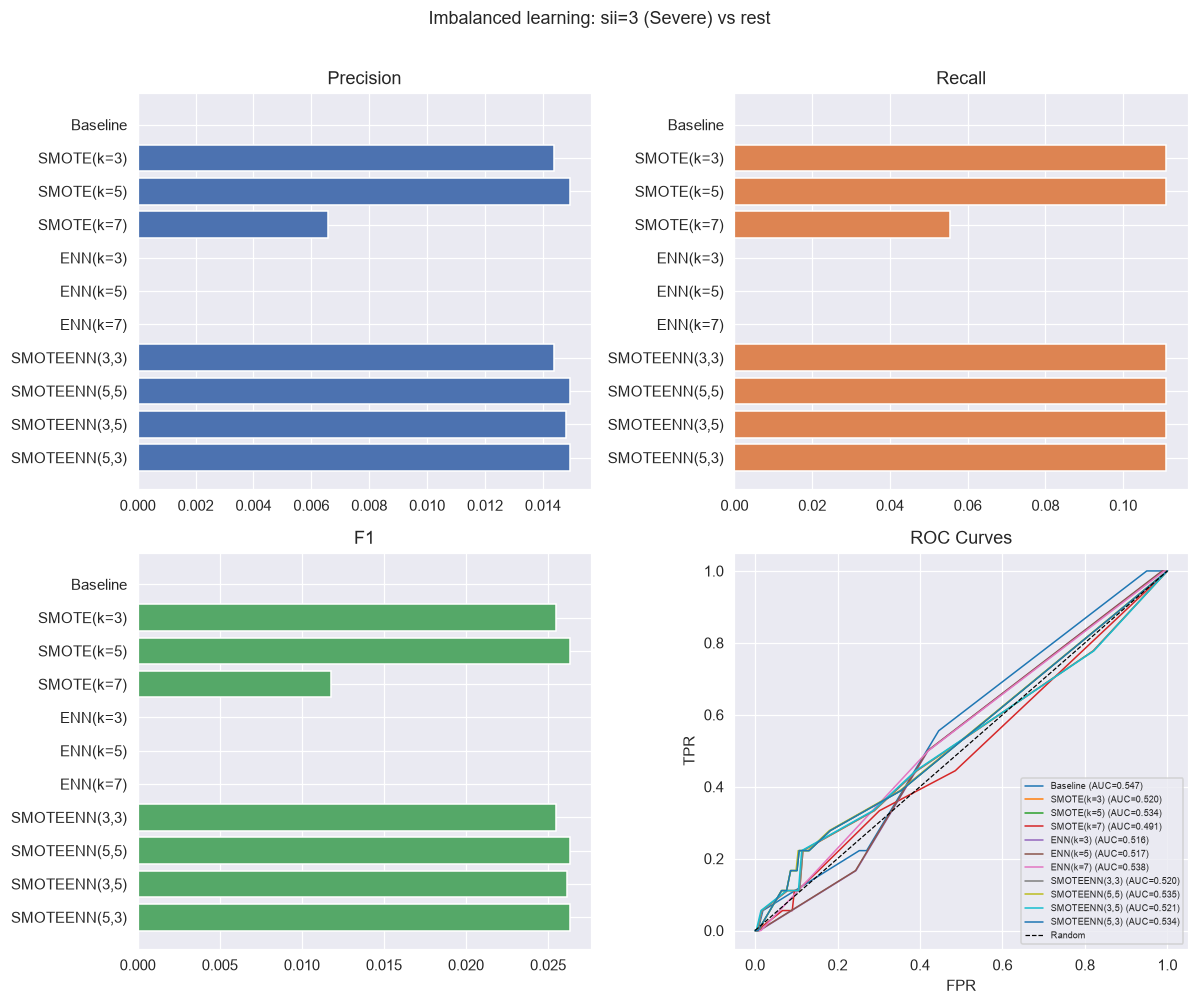

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, metric, color in [
    (axes[0,0], 'Precision', '#4C72B0'),
    (axes[0,1], 'Recall',    '#DD8452'),
    (axes[1,0], 'F1',        '#55A868'),
]:
    ax.barh(results_df['Technique'], results_df[metric], color=color)
    ax.set_title(metric); ax.invert_yaxis()

for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[results_df['Technique']==name, 'AUC'].values[0]
    axes[1,1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1)
axes[1,1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[1,1].set_title('ROC Curves'); axes[1,1].set_xlabel('FPR'); axes[1,1].set_ylabel('TPR')
axes[1,1].legend(fontsize=6, loc='lower right')

plt.suptitle('Imbalanced learning: sii=3 (Severe) vs rest', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig8_imbalance_comparison.png', dpi=110)
plt.show()

In [14]:
print("✅ Module 1 complete. Outputs saved to:", OUT_DIR)
print("Next: run 02_classification.ipynb")

✅ Module 1 complete. Outputs saved to: ../outputs/
Next: run 02_classification.ipynb
